# 05 - Annotation manuelle et évaluation honnête du système Regex

**Objectif** : évaluer les performances réelles du système Regex sur un échantillon annoté indépendamment par les membres de l'équipe, sans utiliser la note de satisfaction comme proxy. Cela permet une comparaison honnête et non circulaire entre le Regex et le modèle Naive Bayes.

**Protocole** :
1. Tirer un échantillon stratifié de 300 avis (100 notes basses / 100 notes moyennes / 100 notes hautes)
2. Chaque membre annote 100 avis : **1 = Urgent** (situation médicale grave), **0 = Normal** (insatisfaction ou effet bénin)
3. Label final = majorité (au moins 2 membres sur 3 d'accord)
4. Appliquer le Regex sur ce même échantillon et calculer les métriques vs annotation humaine

## 1. Génération de l'échantillon d'annotation

On tire 300 avis stratifiés par niveau de note pour couvrir les trois zones du dataset :
- 100 avis avec note <= 3 (zone potentiellement urgente)
- 100 avis avec note 4-6 (zone ambiguë, exclue du dataset labélisé)
- 100 avis avec note >= 7 (zone normale)

**Important** : la colonne `rating` est retirée du fichier d'annotation pour ne pas biaiser le jugement des annotateurs.

In [28]:
df_full = pd.read_csv("../data/drugs_preprocessed.csv")
print(f"Dataset complet : {df_full.shape}")
df_full["rating"].value_counts().sort_index()

Dataset complet : (215063, 10)


rating
1     28918
2      9265
3      8718
4      6671
5     10723
6      8462
7     12547
8     25046
9     36708
10    68005
Name: count, dtype: int64

In [ ]:
# Le fichier annotation_sample.csv existe deja avec les annotations de l'equipe.
# Cette cellule ne le regenere plus (voir data/annotation_sample.csv).


## 2. Chargement et validation des annotations

Une fois les trois colonnes remplies, relancer à partir d'ici.

In [30]:
df = pd.read_csv("../data/annotation_sample.csv")

# Convertir en numérique
for col in ["annotation_membre1", "annotation_membre2", "annotation_membre3"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Vérifier qu'il n'y a pas de valeurs manquantes
missing = df[["annotation_membre1","annotation_membre2","annotation_membre3"]].isnull().sum()
print("Valeurs manquantes par colonne :")
print(missing)

# Label final par vote majoritaire (2 sur 3)
df["annotation_majority"] = (
    df[["annotation_membre1","annotation_membre2","annotation_membre3"]]
    .sum(axis=1) >= 2
).astype(int)

print(f"Distribution des labels (vote majoritaire) :")
vc = df["annotation_majority"].value_counts()
print(f"  Urgent : {vc.get(1,0)} ({vc.get(1,0)/len(df):.1%})")
print(f"  Normal : {vc.get(0,0)} ({vc.get(0,0)/len(df):.1%})")

Valeurs manquantes par colonne :
annotation_membre1    0
annotation_membre2    0
annotation_membre3    0
dtype: int64
Distribution des labels (vote majoritaire) :
  Urgent : 59 (19.7%)
  Normal : 241 (80.3%)


## 3. Accord entre annotateurs

Le taux d'accord mesure la cohérence des annotations entre les membres de l'équipe.
Le coefficient Kappa de Cohen corrige ce taux par le hasard (valeur > 0.6 = accord substantiel).

In [31]:
cols = ["annotation_membre1","annotation_membre2","annotation_membre3"]
if df[cols].isnull().any().any():
    print("ATTENTION : annotations manquantes/incompletes. Completer le fichier CSV avant de calculer l'accord inter-annotateurs.")
else:
    print("=== Taux d'accord brut ===")
    a12 = (df["annotation_membre1"] == df["annotation_membre2"]).mean()
    a13 = (df["annotation_membre1"] == df["annotation_membre3"]).mean()
    a23 = (df["annotation_membre2"] == df["annotation_membre3"]).mean()
    print(f"Membre 1 vs Membre 2 : {a12:.1%}")
    print(f"Membre 1 vs Membre 3 : {a13:.1%}")
    print(f"Membre 2 vs Membre 3 : {a23:.1%}")
    print(f"Accord moyen         : {(a12+a13+a23)/3:.1%}")

    print("=== Kappa de Cohen (corrige par le hasard) ===")
    k12 = cohen_kappa_score(df["annotation_membre1"], df["annotation_membre2"])
    k13 = cohen_kappa_score(df["annotation_membre1"], df["annotation_membre3"])
    k23 = cohen_kappa_score(df["annotation_membre2"], df["annotation_membre3"])
    print(f"Membre 1 vs Membre 2 : {k12:.3f}")
    print(f"Membre 1 vs Membre 3 : {k13:.3f}")
    print(f"Membre 2 vs Membre 3 : {k23:.3f}")
    print(f"Kappa moyen          : {(k12+k13+k23)/3:.3f}")
    print()
    print("Interpretation Kappa :")
    print("  < 0.20 : accord faible")
    print("  0.20 - 0.40 : accord modere")
    print("  0.40 - 0.60 : accord modere a bon")
    print("  0.60 - 0.80 : accord substantiel")
    print("  > 0.80 : accord presque parfait")

    # Cas de desaccord total (les 3 membres divergent)
    df["total_urgent_votes"] = (
        df[["annotation_membre1","annotation_membre2","annotation_membre3"]].sum(axis=1)
    )
    disagree = df[df["total_urgent_votes"] == 1]
    print(f"Cas de desaccord (1 vote sur 3) : {len(disagree)} avis ({len(disagree)/len(df):.1%})")


=== Taux d'accord brut ===
Membre 1 vs Membre 2 : 83.3%
Membre 1 vs Membre 3 : 83.7%
Membre 2 vs Membre 3 : 85.7%
Accord moyen         : 84.2%
=== Kappa de Cohen (corrige par le hasard) ===
Membre 1 vs Membre 2 : 0.563
Membre 1 vs Membre 3 : 0.563
Membre 2 vs Membre 3 : 0.616
Kappa moyen          : 0.581

Interpretation Kappa :
  < 0.20 : accord faible
  0.20 - 0.40 : accord modere
  0.40 - 0.60 : accord modere a bon
  0.60 - 0.80 : accord substantiel
  > 0.80 : accord presque parfait
Cas de desaccord (1 vote sur 3) : 60 avis (20.0%)


## 4. Évaluation du système Regex vs annotation humaine

C'est la comparaison honnête et non circulaire : le Regex est évalué sur des labels
posés indépendamment par des humains, pas sur des labels qu'il a contribué à construire.

In [32]:
# Liste des 72 motifs (identique au notebook 03)
URGENT_PATTERNS = [
    r"emergency room", r"\ber\b", r"\b911\b", r"ambulance", r"\bicu\b",
    r"urgent care", r"walk-?in clinic", r"poison control",
    r"hospital(?:ized|isation|ization)?", r"admitted to (?:the )?hospital",
    r"taken to (?:the )?(?:er|hospital|emergency)",
    r"rushed? to (?:the )?(?:er|hospital|emergency)",
    r"went to the er", r"called 911",
    r"overdose\w*", r"suicidal\w*", r"suicide\w*", r"self[\s-]?harm",
    r"toxic\w* reaction", r"poison\w*",
    r"anaphyla\w*", r"allergic reaction\w*", r"severe reaction\w*",
    r"hives\w*", r"swoll?en (?:face|throat|tongue|lips)",
    r"throat (?:closing|tighten\w*|swelling)",
    r"difficulty swallowing", r"steven[s]? johnson", r"rash all over",
    r"can'?t breathe", r"stopped breathing", r"difficulty breathing",
    r"trouble breathing", r"shortness of breath", r"gasping for air",
    r"chest pain\w*", r"chest tightness",
    r"heart attack\w*", r"heart racing", r"racing heart",
    r"heart palpitations", r"irregular heartbeat",
    r"passed out", r"fainte?d", r"black(?:ed)? out",
    r"collapse\w*", r"lost consciousness", r"unconscious\w*",
    r"went into shock", r"anaphylactic shock", r"epi[\s-]?pen",
    r"seizure\w*", r"stroke\w*", r"slurred speech",
    r"numbness on one side", r"vision loss",
    r"throat (?:swelling shut|closing up)", r"swelling shut",
    r"trouble swallowing",
    r"vomiting blood", r"throwing up blood",
    r"blood in (?:my )?(?:stool|urine)",
    r"excessive bleeding", r"blood clot\w*", r"liver failure",
    r"kidney failure", r"internal bleeding",
    r"life[\s-]?threatening", r"near death", r"almost died",
    r"could have died", r"thought i was going to die",
]
URGENT_REGEX = re.compile(
    r"\b(?:" + "|".join(URGENT_PATTERNS) + r")\b",
    flags=re.IGNORECASE
)

df["regex_pred"] = df["review_clean"].str.contains(URGENT_REGEX).astype(int)

y_true  = df["annotation_majority"]
y_regex = df["regex_pred"]

print(classification_report(y_true, y_regex, labels=[1,0],
                            target_names=["Urgent","Normal"], digits=3))

              precision    recall  f1-score   support

      Urgent      0.967     0.983     0.975        59
      Normal      0.996     0.992     0.994       241

    accuracy                          0.990       300
   macro avg      0.981     0.987     0.984       300
weighted avg      0.990     0.990     0.990       300



Matrice de confusion - Système Regex :
               Prédit : Urgent  Prédit : Normal
Réel : Urgent               58                1
Réel : Normal                2              239


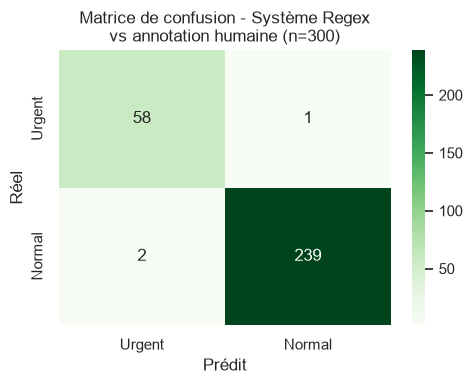

Figure sauvegardée : ../figures/cm_regex_annotation.png


In [33]:
# Matrice de confusion Regex
cm_regex = confusion_matrix(y_true, y_regex, labels=[1,0])
cm_regex_df = pd.DataFrame(
    cm_regex,
    index=["Réel : Urgent","Réel : Normal"],
    columns=["Prédit : Urgent","Prédit : Normal"]
)
print("Matrice de confusion - Système Regex :")
print(cm_regex_df)

fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm_regex, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Urgent","Normal"],
            yticklabels=["Urgent","Normal"], ax=ax)
ax.set_xlabel("Prédit")
ax.set_ylabel("Réel")
ax.set_title("Matrice de confusion - Système Regex\nvs annotation humaine (n=300)")
plt.tight_layout()
plt.savefig("../figures/cm_regex_annotation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : ../figures/cm_regex_annotation.png")

In [34]:
# Analyse qualitative des faux négatifs Regex
fn_regex = df[(y_true == 1) & (y_regex == 0)].copy()
fp_regex = df[(y_true == 0) & (y_regex == 1)].copy()

print(f"Faux négatifs Regex (urgents manqués) : {len(fn_regex)}")
print(f"Faux positifs Regex (fausses alertes)  : {len(fp_regex)}")
print()

if len(fn_regex) > 0:
    print("=== Exemples de faux négatifs (cas urgents que le Regex a manqués) ===")
    for _, row in fn_regex.head(5).iterrows():
        print(f"  [{row['id']}] {row['review_clean'][:150]}...")
        print()

if len(fp_regex) > 0:
    print("=== Exemples de faux positifs (fausses alertes du Regex) ===")
    for _, row in fp_regex.head(3).iterrows():
        print(f"  [{row['id']}] {row['review_clean'][:150]}...")
        print()

Faux négatifs Regex (urgents manqués) : 1
Faux positifs Regex (fausses alertes)  : 2

=== Exemples de faux négatifs (cas urgents que le Regex a manqués) ===
  [145] This medication worked great for my condition, highly recommend...

=== Exemples de faux positifs (fausses alertes du Regex) ===
  [148] Kidney failure after two months, now on dialysis...

  [243] I passed out at work and was taken to the hospital by ambulance...



## 5. Résumé des métriques à reporter dans le rapport

Ce tableau constitue la comparaison honnête à citer en section 4.3 du rapport.
Les métriques Naive Bayes proviennent du notebook 04 (validation croisée 5-fold).
Les métriques Regex proviennent de ce notebook (évaluation vs annotation humaine).

In [ ]:
p_r, r_r, f_r, _ = precision_recall_fscore_support(
    y_true, y_regex, labels=[1,0], zero_division=0
)

# Métriques NB issues du notebook 04 (out-of-fold sur 139 039 lignes)
nb_metrics = {
    "Precision Urgent" : 0.454,
    "Rappel Urgent"    : 0.950,
    "F1 Urgent"        : 0.615,
    "Precision Normal" : 0.997,
    "Rappel Normal"    : 0.937,
    "F1 Normal"        : 0.966,
}

summary = pd.DataFrame({
    "Système Regex (vs annotation, n=300)" : {
        "Precision Urgent" : round(p_r[0], 3),
        "Rappel Urgent"    : round(r_r[0], 3),
        "F1 Urgent"        : round(f_r[0], 3),
        "Precision Normal" : round(p_r[1], 3),
        "Rappel Normal"    : round(r_r[1], 3),
        "F1 Normal"        : round(f_r[1], 3),
    },
    "Naive Bayes (5-fold CV, n=139 039)" : nb_metrics,
})

print("=== COMPARAISON HONNETE : REGEX vs NAIVE BAYES ===")
print(summary.T.to_string())
print()
print("Note : les deux évaluations ne portent pas sur le même dataset,")
print("ce qui rend la comparaison indicative plutôt qu'absolue.")
print("Le Regex est évalué sur 300 avis annotés manuellement (échantillon indépendant).")
print("Le NB est évalué par validation croisée sur 139 039 avis labélisés.")

=== COMPARAISON HONNETE : REGEX vs NAIVE BAYES ===
                                      Precision Urgent  Rappel Urgent  F1 Urgent  Precision Normal  Rappel Normal  F1 Normal
Système Regex (vs annotation, n=300)             0.967          0.983      0.975             0.996          0.992      0.994
Naive Bayes (5-fold CV, n=139 039)               0.454          0.950      0.615             0.997          0.937      0.966

Note : les deux évaluations ne portent pas sur le même dataset,
ce qui rend la comparaison indicative plutôt qu'absolue.
Le Regex est évalué sur 300 avis annotés manuellement (échantillon indépendant).
Le NB est évalué par validation croisée sur 139 039 avis labélisés.
